# 05 · Simulador de Ciclos Sintéticos — Validação do Gatilho RED

**Objetivo:** gerar séries temporais sintéticas de força de selagem que repliquem o padrão
vectorial dos dados reais, definir um momento de troca e verificar se o gatilho RED
dispara a tempo — idealmente com **criticidade máxima** nos últimos dias antes da troca.

## Modelo de força sintético

Três fases por ciclo (calibradas nos dados históricos FB14):

| Fase | Duração | Comportamento |
|---|---|---|
| Acomodamento | 0–72h | Força crescendo até estabilizar |
| Estável | 72h → `onset_pct`% | Drift ≈ 0, ruído AR(1) |
| Degradação | `onset_pct`% → 100% | Queda progressiva (power-law) |

Parâmetros calibrados nos 23 ciclos históricos completos:
- Força inicial: 1053 N (mediana)
- Força final (genuíno): 661–800 N
- Duração genuíno: 49–185 dias
- Ruído AR(1): ρ=0.97, σ≈50 N

| Etapa | Descrição |
|---|---|
| A | Modelo de força sintético e gerador de série |
| B | Cenário único: ciclo genuíno vs. preventivo |
| C | Monte Carlo — 200 simulações, medir detecção e antecedência |
| D | Análise de sensibilidade — onset_pct e media_final |
| E | Resumo: limites de detecção do gatilho RED |

In [1]:
import sys, warnings, tempfile
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from datetime import datetime, timedelta

from src.trigger_engine import (
    TriggerEngine, compute_p_risk_snapshot,
    LIMIAR_P_RISK, LIMIAR_SIGNAL_SCORE, PROJ_48H_LIMIAR,
    IDADE_MINIMA_DIAS, WEIBULL_BETA, WEIBULL_ETA_D,
)

# ── Semente global de reprodutibilidade ──────────────────────────────────────
GLOBAL_SEED  = 2024
MEAN_INICIAL = 1100.0   # N — força típica no início do ciclo
SIGMA_RUIDO  = 50.0     # N — desvio padrão inovação AR(1)
RHO_AR1      = 0.97     # coeficiente de autocorrelação horária
DIURNAL_AMP  = 25.0     # N — amplitude da variação diurna

# Data de referência para os timestamps sintéticos
DATA_REF = datetime(2026, 6, 1)

print('Parâmetros do simulador:')
print(f'  Força inicial      : {MEAN_INICIAL} N')
print(f'  Ruído AR(1) σ      : {SIGMA_RUIDO} N,  ρ = {RHO_AR1}')
print(f'  Variação diurna    : ±{DIURNAL_AMP} N')
print(f'  Weibull β={WEIBULL_BETA}, η={WEIBULL_ETA_D:.1f}d')
print(f'  Limiar RED p_risk  : {LIMIAR_P_RISK}  |  signal_score: {LIMIAR_SIGNAL_SCORE}')
print('Módulos OK')

Parâmetros do simulador:
  Força inicial      : 1100.0 N
  Ruído AR(1) σ      : 50.0 N,  ρ = 0.97
  Variação diurna    : ±25.0 N
  Weibull β=1.181, η=54.0d
  Limiar RED p_risk  : 0.48  |  signal_score: 0.22
Módulos OK


## Etapa A — Modelo de força sintético

In [2]:
def gerar_serie_forca(
    duracao_dias: int,
    media_inicial: float = MEAN_INICIAL,
    media_final: float   = 600.0,
    onset_pct: float     = 0.55,
    sigma_ruido: float   = SIGMA_RUIDO,
    rho: float           = RHO_AR1,
    diurnal_amp: float   = DIURNAL_AMP,
    data_inicio: datetime = DATA_REF,
    seed: int            = 42,
) -> pd.DataFrame:
    """
    Gera DataFrame horário com colunas Media, Forca_A, Forca_B.

    Modelo de 3 fases:
      1. Acomodamento (0-72h): força sobe de 85% para 100% do media_inicial
      2. Estável (72h – onset_h): drift ≈ 0
      3. Degradação (onset_h – final): queda power-law para media_final

    Ruído: processo AR(1) com autocorrelação ρ por hora.
    """
    rng = np.random.default_rng(seed)
    n_h = duracao_dias * 24
    t   = np.arange(n_h, dtype=float)
    onset_h = int(onset_pct * n_h)
    settling_h = min(72, int(0.1 * n_h))  # acomodamento: 3 dias ou 10%

    # ── Baseline determinístico ────────────────────────────────────────────
    baseline = np.empty(n_h)
    for i in range(n_h):
        if i < settling_h:                     # fase 1: acomodamento
            alpha = i / settling_h
            baseline[i] = media_inicial * (0.82 + 0.18 * alpha)
        elif i < onset_h:                      # fase 2: estável
            baseline[i] = media_inicial
        else:                                  # fase 3: degradação
            prog = (i - onset_h) / max(1, n_h - onset_h)
            # power-law com expoente 1.8 → queda acelera no final
            baseline[i] = media_inicial + (media_final - media_inicial) * (prog ** 1.8)

    # ── Ruído AR(1) ───────────────────────────────────────────────────────
    sigma_innov = sigma_ruido * np.sqrt(1 - rho ** 2)
    eps = rng.normal(0, sigma_innov, n_h)
    ar_noise = np.empty(n_h)
    ar_noise[0] = eps[0]
    for i in range(1, n_h):
        ar_noise[i] = rho * ar_noise[i - 1] + eps[i]

    # ── Variação diurna ───────────────────────────────────────────────────
    hora_dia = (t % 24).astype(int)
    diurnal  = diurnal_amp * np.sin(2 * np.pi * hora_dia / 24)

    # ── Força composta ────────────────────────────────────────────────────
    F = baseline + ar_noise + diurnal
    F = np.clip(F, 200.0, 2500.0)  # limites físicos

    # ── Assimetria A/B (desgaste diferencial realista) ────────────────────
    desbalanco = 0.05 + 0.05 * np.linspace(0, 1, n_h)  # cresce com o tempo
    Fa = F * (1 + desbalanco / 2) + rng.normal(0, 15, n_h)
    Fb = F * (1 - desbalanco / 2) + rng.normal(0, 15, n_h)
    Fa = np.clip(Fa, 200, 2500)
    Fb = np.clip(Fb, 200, 2500)

    ts = pd.date_range(data_inicio, periods=n_h, freq='h')
    df = pd.DataFrame({'Media': F, 'Forca_A': Fa, 'Forca_B': Fb}, index=ts)
    return df


print('Função gerar_serie_forca() OK')
print()

# ── Verificar estatísticas de um ciclo de exemplo ─────────────────────────
exemplo = gerar_serie_forca(75, media_final=580.0, onset_pct=0.55, seed=GLOBAL_SEED)
print('Ciclo exemplo (75d, final=580N):')
print(f'  N horas      : {len(exemplo)}')
print(f'  Media global : {exemplo["Media"].mean():.0f} N  (std={exemplo["Media"].std():.0f} N)')
print(f'  Media [0-72h]: {exemplo["Media"].iloc[:72].mean():.0f} N')
print(f'  Media [-72h] : {exemplo["Media"].iloc[-72:].mean():.0f} N')
print(f'  Min          : {exemplo["Media"].min():.0f} N')
print(f'  Max          : {exemplo["Media"].max():.0f} N')

Função gerar_serie_forca() OK

Ciclo exemplo (75d, final=580N):
  N horas      : 1800
  Media global : 1009 N  (std=156 N)
  Media [0-72h]: 1010 N
  Media [-72h] : 561 N
  Min          : 532 N
  Max          : 1214 N


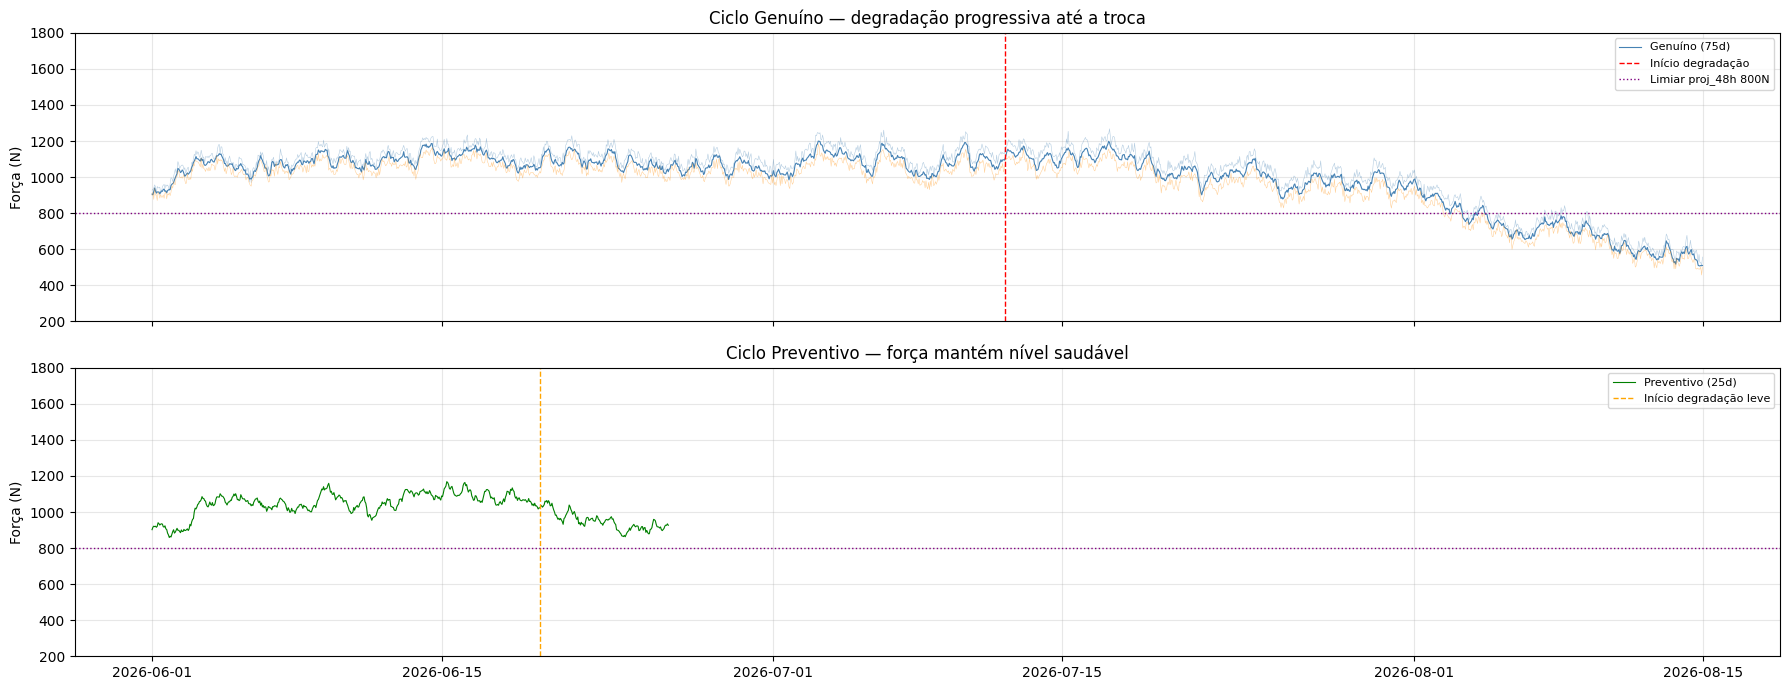

Figura 1: modelo de fases OK


In [3]:
# ── Visualizar as 3 fases do modelo ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 7), sharex=True)

df_ex  = gerar_serie_forca(75, media_final=580.0, onset_pct=0.55, seed=42)
df_prev = gerar_serie_forca(25, media_final=950.0, onset_pct=0.75, seed=7)

# Ciclo genuíno
axes[0].plot(df_ex.index, df_ex['Media'], lw=0.8, color='steelblue', label='Genuíno (75d)')
axes[0].plot(df_ex.index, df_ex['Forca_A'], lw=0.4, color='steelblue', alpha=0.4)
axes[0].plot(df_ex.index, df_ex['Forca_B'], lw=0.4, color='darkorange', alpha=0.4)
onset_h = int(0.55 * len(df_ex))
axes[0].axvline(df_ex.index[onset_h], color='red', ls='--', lw=1.0, label='Início degradação')
axes[0].axhline(PROJ_48H_LIMIAR, color='purple', ls=':', lw=1.0, label=f'Limiar proj_48h {PROJ_48H_LIMIAR:.0f}N')
axes[0].set_ylabel('Força (N)')
axes[0].set_title('Ciclo Genuíno — degradação progressiva até a troca')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(200, 1800)

# Ciclo preventivo
axes[1].plot(df_prev.index, df_prev['Media'], lw=0.8, color='green', label='Preventivo (25d)')
onset_h2 = int(0.75 * len(df_prev))
axes[1].axvline(df_prev.index[onset_h2], color='orange', ls='--', lw=1.0, label='Início degradação leve')
axes[1].axhline(PROJ_48H_LIMIAR, color='purple', ls=':', lw=1.0)
axes[1].set_ylabel('Força (N)')
axes[1].set_title('Ciclo Preventivo — força mantém nível saudável')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(200, 1800)

plt.tight_layout()
plt.savefig('05_modelo_fases.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura 1: modelo de fases OK')

## Etapa B — Cenário único: ciclo genuíno vs. preventivo

Roda o trigger engine dia a dia e mostra p_risk + momento do disparo RED.

In [4]:
def simular_engine(
    df_ciclo: pd.DataFrame,
    troca_date: datetime,
    seed_label: str = '',
) -> tuple[list[dict], list[dict]]:
    """
    Roda TriggerEngine dia a dia sobre df_ciclo.
    Retorna (disparos, snapshots_diarios).
    """
    state_path = Path(tempfile.mktemp(suffix='.json'))
    if state_path.exists():
        state_path.unlink()
    engine = TriggerEngine('SIM', state_path)

    # Garante que o índice não tenha fuso horário (engine opera naive)
    df = df_ciclo.copy()
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
    troca_dt = pd.Timestamp(troca_date)

    dias = pd.DatetimeIndex(sorted({ts.normalize() for ts in df.index}))
    disparos   = []
    snapshots  = []

    for day in dias:
        df_ate = df[df.index <= day + pd.Timedelta(hours=23, minutes=59)]
        if df_ate.empty:
            continue

        # Snapshot diário (sem cooldown — apenas p_risk)
        snap = compute_p_risk_snapshot(df_ate, troca_date, day)
        snap['day'] = day
        snapshots.append(snap)

        # Avaliação do engine (considera cooldown/snooze)
        try:
            evs = engine.evaluate(df_ate, troca_date, sp_client=None, today=day)
        except Exception as exc:
            print(f'[ERRO] {day.date()}: {exc}')
            continue

        for ev in evs:
            disparos.append({
                'day': day, 'gatilho': ev.gatilho,
                'p_risk': ev.score_atual, 'signal_score': ev.signal_score,
                'age_risk': ev.age_risk, 'proj_48h': ev.proj_48h,
                'slope_7d': ev.slope_forca_7d, 'mean_3d': ev.forca_minima_3d,
                'idade_dias': ev.idade_maintacker,
            })

    if state_path.exists():
        state_path.unlink()
    return disparos, snapshots


print('Função simular_engine() OK')

Função simular_engine() OK


In [5]:
# ── Cenário A: ciclo genuíno (75d, queda para 580N) ──────────────────────
troca_a = DATA_REF
df_a    = gerar_serie_forca(75, media_final=580.0, onset_pct=0.55, seed=GLOBAL_SEED)

disparos_a, snaps_a = simular_engine(df_a, troca_a, 'genuino')

print('=== CENÁRIO A — Rolo Genuíno (75d, queda 1100→580N) ===')
if disparos_a:
    d1 = disparos_a[0]
    troca_fim_a = troca_a + timedelta(days=75)
    ant = (troca_fim_a - d1['day'].to_pydatetime()).days
    print(f'  RED disparou em    : {d1["day"].date()}  (dia {d1["idade_dias"]} do ciclo)')
    print(f'  Antecedência       : {ant} dias antes da troca')
    print(f'  p_risk             : {d1["p_risk"]:.3f}  ({d1["p_risk"]*100:.0f}%)')
    print(f'  signal_score       : {d1["signal_score"]:.3f}')
    #print(f'  proj_48h           : {d1["proj_48h"]:.0f} N')
    print(f'  Total disparos RED : {len(disparos_a)}')
else:
    print('  Nenhum disparo RED — verificar parâmetros!')

print()
print('=== CENÁRIO B — Rolo Preventivo (25d, queda 1100→950N) ===')
troca_b = DATA_REF
df_b    = gerar_serie_forca(25, media_final=950.0, onset_pct=0.75, seed=GLOBAL_SEED + 1)
disparos_b, snaps_b = simular_engine(df_b, troca_b, 'preventivo')

if disparos_b:
    d1b = disparos_b[0]
    print(f'  [!] RED DISPAROU inesperadamente em {d1b["day"].date()}')
    print(f'      p_risk={d1b["p_risk"]:.3f}  signal={d1b["signal_score"]:.3f}')
else:
    print('  Nenhum disparo RED — CORRETO (ciclo preventivo saudável)')

[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[2026-08-01] EMERGENCIA disparada: min_3d=789 N (limite=800 N)
[dry-run] EMERGENCIA nao persistido (sp_client=None).
[2026-08-03] EME

=== CENÁRIO A — Rolo Genuíno (75d, queda 1100→580N) ===
  RED disparou em    : 2026-06-17  (dia 16 do ciclo)
  Antecedência       : 59 dias antes da troca
  p_risk             : 0.321  (32%)
  signal_score       : 0.213
  Total disparos RED : 30

=== CENÁRIO B — Rolo Preventivo (25d, queda 1100→950N) ===
  [!] RED DISPAROU inesperadamente em 2026-06-21
      p_risk=0.292  signal=0.055


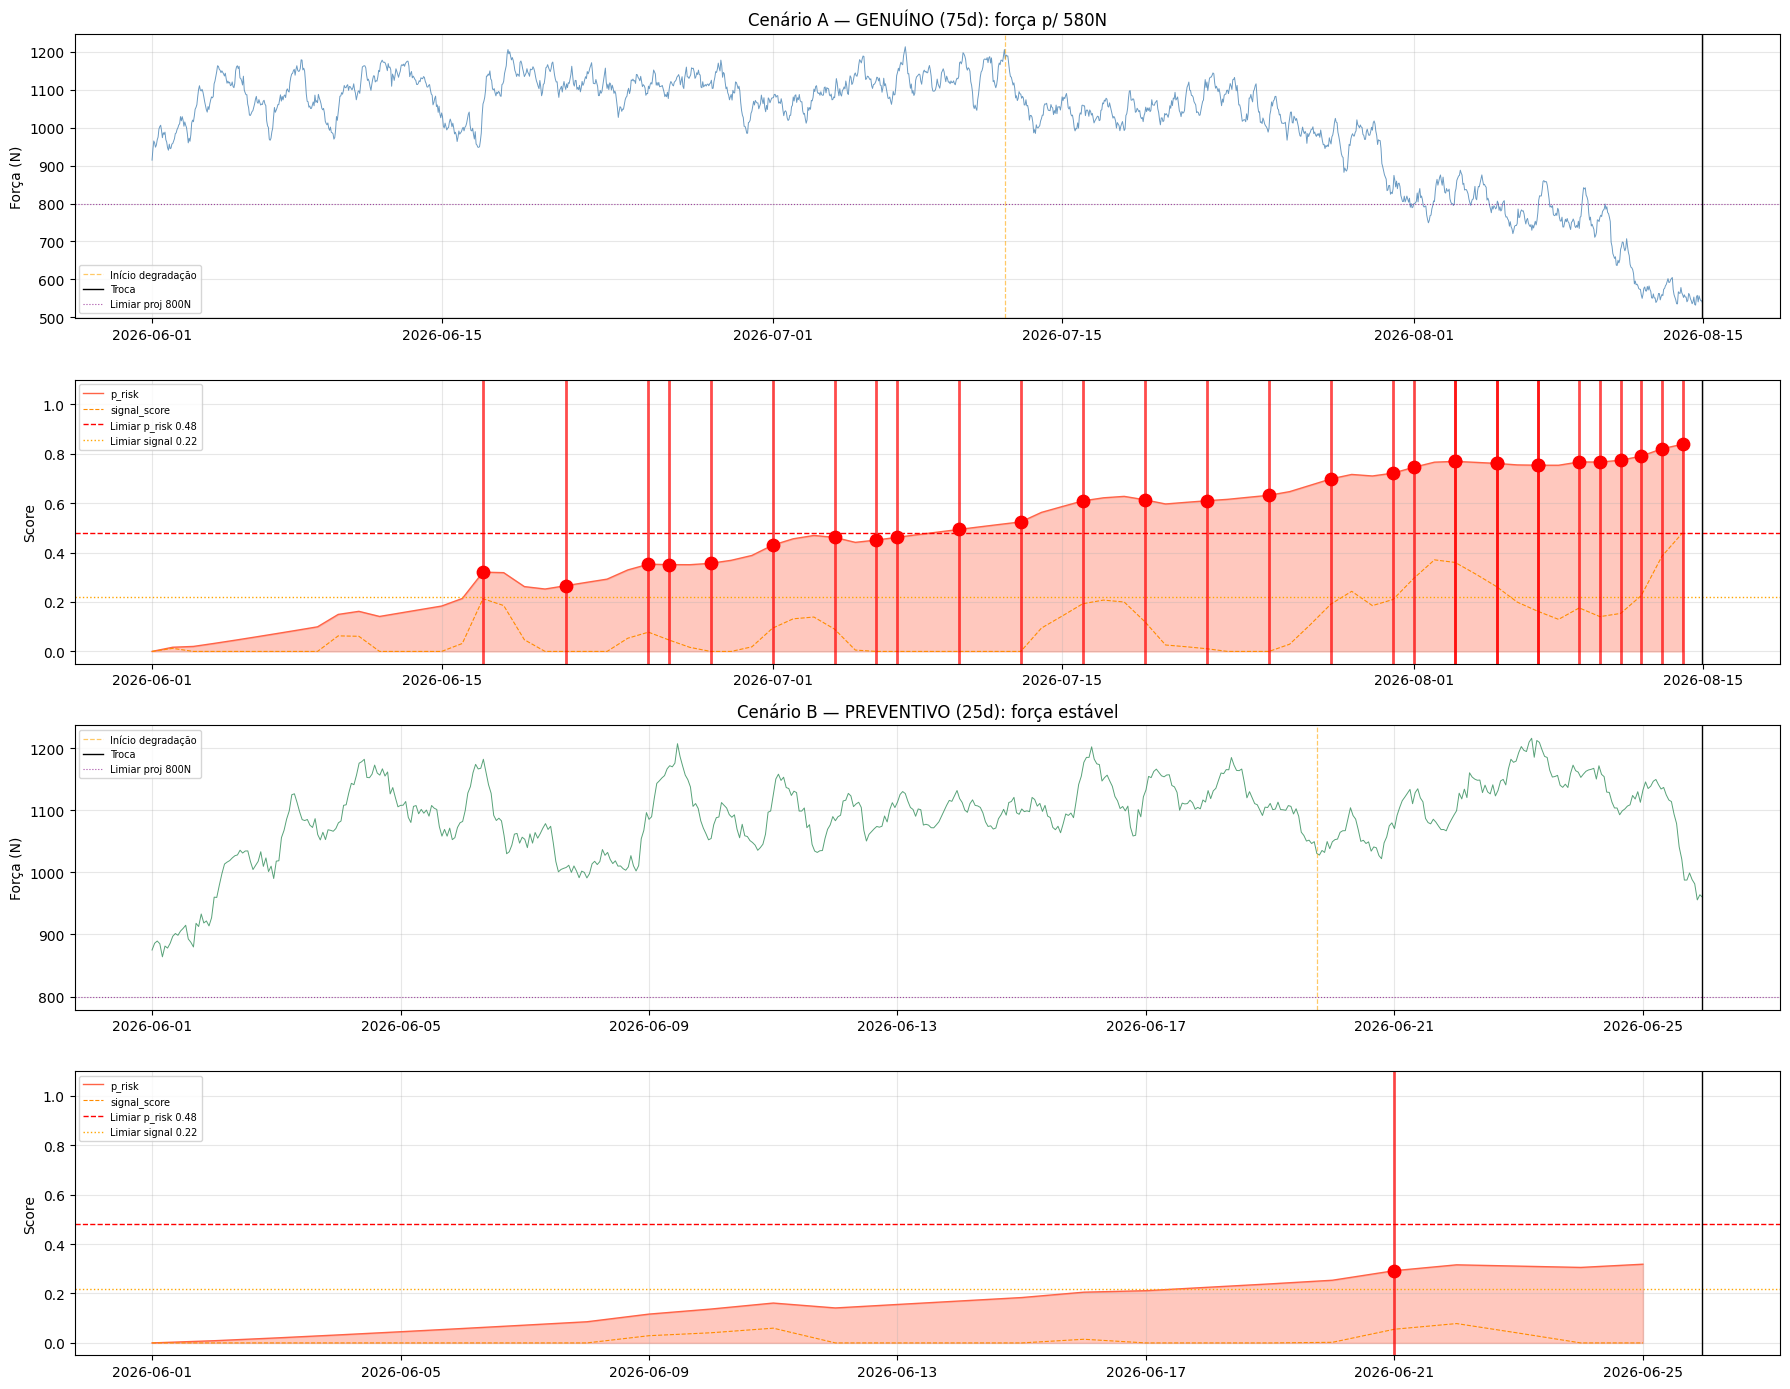

In [6]:
# ── Visualizar p_risk + Media + disparo RED para os dois cenários ──────────
def _plot_cenario(df_ciclo, troca_date, disparos, snapshots, duracao_d,
                  titulo, ax_f, ax_p, cor='steelblue'):
    # Força
    ax_f.plot(df_ciclo.index, df_ciclo['Media'], lw=0.7, color=cor, alpha=0.8)
    onset_h = int(0.55 * len(df_ciclo)) if duracao_d > 30 else int(0.75 * len(df_ciclo))
    ax_f.axvline(df_ciclo.index[onset_h], color='orange', ls='--', lw=0.9, alpha=0.6,
                 label='Início degradação')
    ax_f.axvline(df_ciclo.index[-1], color='black', lw=1.0, label='Troca')
    ax_f.axhline(PROJ_48H_LIMIAR, color='purple', ls=':', lw=0.8, alpha=0.7,
                 label=f'Limiar proj {PROJ_48H_LIMIAR:.0f}N')
    ax_f.set_ylabel('Força (N)')
    ax_f.set_title(titulo)
    ax_f.legend(fontsize=7)
    ax_f.grid(alpha=0.3)

    # p_risk
    snap_df = pd.DataFrame(snapshots).set_index('day')
    ax_p.fill_between(snap_df.index, snap_df['p_risk'], color='tomato', alpha=0.35)
    ax_p.plot(snap_df.index, snap_df['p_risk'], lw=1.0, color='tomato', label='p_risk')
    ax_p.plot(snap_df.index, snap_df['sig_score'], lw=0.8, color='darkorange',
              ls='--', label='signal_score')
    ax_p.axhline(LIMIAR_P_RISK, color='red', ls='--', lw=1.0,
                 label=f'Limiar p_risk {LIMIAR_P_RISK}')
    ax_p.axhline(LIMIAR_SIGNAL_SCORE, color='orange', ls=':', lw=1.0,
                 label=f'Limiar signal {LIMIAR_SIGNAL_SCORE}')
    ax_p.axvline(df_ciclo.index[-1], color='black', lw=1.0)
    for d in disparos:
        ax_p.axvline(d['day'], color='red', lw=2.0, alpha=0.7)
        ax_p.scatter(d['day'], d['p_risk'], color='red', s=80, zorder=6)
    ax_p.set_ylabel('Score')
    ax_p.set_ylim(-0.05, 1.1)
    ax_p.legend(fontsize=7)
    ax_p.grid(alpha=0.3)


fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=False)

_plot_cenario(df_a, troca_a, disparos_a, snaps_a, 75,
              'Cenário A — GENUÍNO (75d): força p/ 580N',
              axes[0], axes[1], cor='steelblue')

_plot_cenario(df_b, troca_b, disparos_b, snaps_b, 25,
              'Cenário B — PREVENTIVO (25d): força estável',
              axes[2], axes[3], cor='seagreen')

plt.tight_layout()
plt.savefig('05_cenarios_ab.png', dpi=120, bbox_inches='tight')
plt.show()

## Etapa C — Monte Carlo: 200 simulações

Gera ciclos com parâmetros aleatórios dentro dos intervalos observados nos dados reais.
Mede detecção (RED disparou?) e antecedência (quantos dias antes da troca?).

In [7]:
N_SIM = 200
rng_mc = np.random.default_rng(GLOBAL_SEED)

resultados = []

for sim_i in range(N_SIM):
    seed_i = int(rng_mc.integers(0, 99999))

    # ── Parâmetros aleatórios (baseados nos ciclos reais) ─────────────────
    duracao_d   = int(rng_mc.uniform(20, 130))   # dias
    media_ini   = float(rng_mc.normal(1060, 100))  # N
    onset_pct   = float(rng_mc.uniform(0.40, 0.75))
    sigma_r     = float(rng_mc.uniform(35, 70))

    # Força final depende da duração:
    # ciclos longos tendem a degradar mais
    if duracao_d >= 45:
        # ciclo genuíno: queda significativa
        media_final = float(rng_mc.uniform(400, 850))
        tipo = 'genuino'
    else:
        # ciclo curto: pode ser preventivo (pouca queda) ou genuíno raro
        p_genuino = max(0.0, (duracao_d - 20) / 30.0)  # 0% em 20d, 100% em 50d
        if rng_mc.random() < p_genuino:
            media_final = float(rng_mc.uniform(500, 800))
            tipo = 'genuino'
        else:
            media_final = float(rng_mc.uniform(850, 1050))
            tipo = 'preventivo'

    # ── Gerar série e rodar engine ────────────────────────────────────────
    try:
        df_sim = gerar_serie_forca(
            duracao_d, media_inicial=media_ini,
            media_final=media_final, onset_pct=onset_pct,
            sigma_ruido=sigma_r, seed=seed_i,
        )
        disparos_sim, _ = simular_engine(df_sim, DATA_REF, f'sim_{sim_i}')
    except Exception as exc:
        print(f'  [ERRO] sim {sim_i}: {exc}')
        continue

    # ── Registrar resultado ───────────────────────────────────────────────
    troca_fim_sim = DATA_REF + timedelta(days=duracao_d)
    if disparos_sim:
        d1 = disparos_sim[0]       # primeiro disparo
        ant = (troca_fim_sim - d1['day'].to_pydatetime()).days
        resultado = {
            'sim_i'        : sim_i,
            'tipo'         : tipo,
            'duracao_d'    : duracao_d,
            'media_ini'    : round(media_ini, 0),
            'media_final'  : round(media_final, 0),
            'onset_pct'    : round(onset_pct, 2),
            'RED'          : True,
            'p_risk_1o'    : round(d1['p_risk'], 3),
            #'signal_1o'    : round(d1['signal_score'], 3),
            'antecedencia' : ant,
            'idade_disparo': d1['idade_dias'],
            'n_disparos'   : len(disparos_sim),
        }
    else:
        resultado = {
            'sim_i'        : sim_i,
            'tipo'         : tipo,
            'duracao_d'    : duracao_d,
            'media_ini'    : round(media_ini, 0),
            'media_final'  : round(media_final, 0),
            'onset_pct'    : round(onset_pct, 2),
            'RED'          : False,
            'p_risk_1o'    : None,
            'signal_1o'    : None,
            'antecedencia' : None,
            'idade_disparo': None,
            'n_disparos'   : 0,
        }
    resultados.append(resultado)

mc_df = pd.DataFrame(resultados)
print(f'Monte Carlo concluído: {N_SIM} simulações')
print()
print('=== RESUMO GERAL ===')
print(mc_df.groupby('tipo')['RED'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'RED_disparou', 'count': 'total', 'mean': 'taxa_deteccao'}
).round(3).to_string())

[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[2026-07-10] EMERGENCIA disparada: min_3d=776 N (limite=800 N)
[dry-run] EMERGENCIA nao persistido (sp_client=None).
[2026-07-12] EMERGENCIA disparada: min_3d=571 N (limite=800 N)
[dry-run] EMERGENCIA nao persistido (sp_client=None).
[dry-run] RED nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[2026-07-04] EMERGENCIA disparada: min_3d=790 N (limite=

Monte Carlo concluído: 200 simulações

=== RESUMO GERAL ===
            RED_disparou  total  taxa_deteccao
tipo                                          
genuino              172    172          1.000
preventivo            25     28          0.893


In [8]:
# ── Estatísticas dos ciclos que dispararam RED ────────────────────────────
genuinos_fire   = mc_df[(mc_df['tipo'] == 'genuino')  & mc_df['RED']]
preventivos_fp  = mc_df[(mc_df['tipo'] == 'preventivo') & mc_df['RED']]
genuinos_miss   = mc_df[(mc_df['tipo'] == 'genuino')  & ~mc_df['RED']]

print('=== Ciclos GENUÍNOS com disparo RED ===')
if not genuinos_fire.empty:
    print(f'  n = {len(genuinos_fire)}')
    print(f'  Antecedência (dias):')
    print(f'    median = {genuinos_fire["antecedencia"].median():.0f}d')
    print(f'    P25    = {genuinos_fire["antecedencia"].quantile(0.25):.0f}d')
    print(f'    P75    = {genuinos_fire["antecedencia"].quantile(0.75):.0f}d')
    print(f'    min    = {genuinos_fire["antecedencia"].min():.0f}d')
    print(f'    max    = {genuinos_fire["antecedencia"].max():.0f}d')
    print(f'  p_risk no 1o disparo: median={genuinos_fire["p_risk_1o"].median():.3f}')
print()
print(f'=== Ciclos GENUÍNOS SEM disparo RED (miss) ===')
if not genuinos_miss.empty:
    print(f'  n = {len(genuinos_miss)}')
    print(f'  Duracao: median={genuinos_miss["duracao_d"].median():.0f}d')
    print(f'  media_final: median={genuinos_miss["media_final"].median():.0f}N')
else:
    print('  Nenhum (deteccao 100% em genuinos)')
print()
print('=== Falsos Positivos (ciclo preventivo disparou RED) ===')
if not preventivos_fp.empty:
    print(f'  n = {len(preventivos_fp)}  ({len(preventivos_fp)/len(mc_df[mc_df["tipo"]=="preventivo"]):.1%})')
    print(f'  media_final: {preventivos_fp["media_final"].describe().round(0).to_dict()}')
else:
    print('  Nenhum falso positivo!')

=== Ciclos GENUÍNOS com disparo RED ===
  n = 172
  Antecedência (dias):
    median = 62d
    P25    = 39d
    P75    = 90d
    min    = 7d
    max    = 114d
  p_risk no 1o disparo: median=0.277

=== Ciclos GENUÍNOS SEM disparo RED (miss) ===
  Nenhum (deteccao 100% em genuinos)

=== Falsos Positivos (ciclo preventivo disparou RED) ===
  n = 25  (89.3%)
  media_final: {'count': 25.0, 'mean': 933.0, 'std': 54.0, 'min': 858.0, '25%': 889.0, '50%': 926.0, '75%': 973.0, 'max': 1038.0}


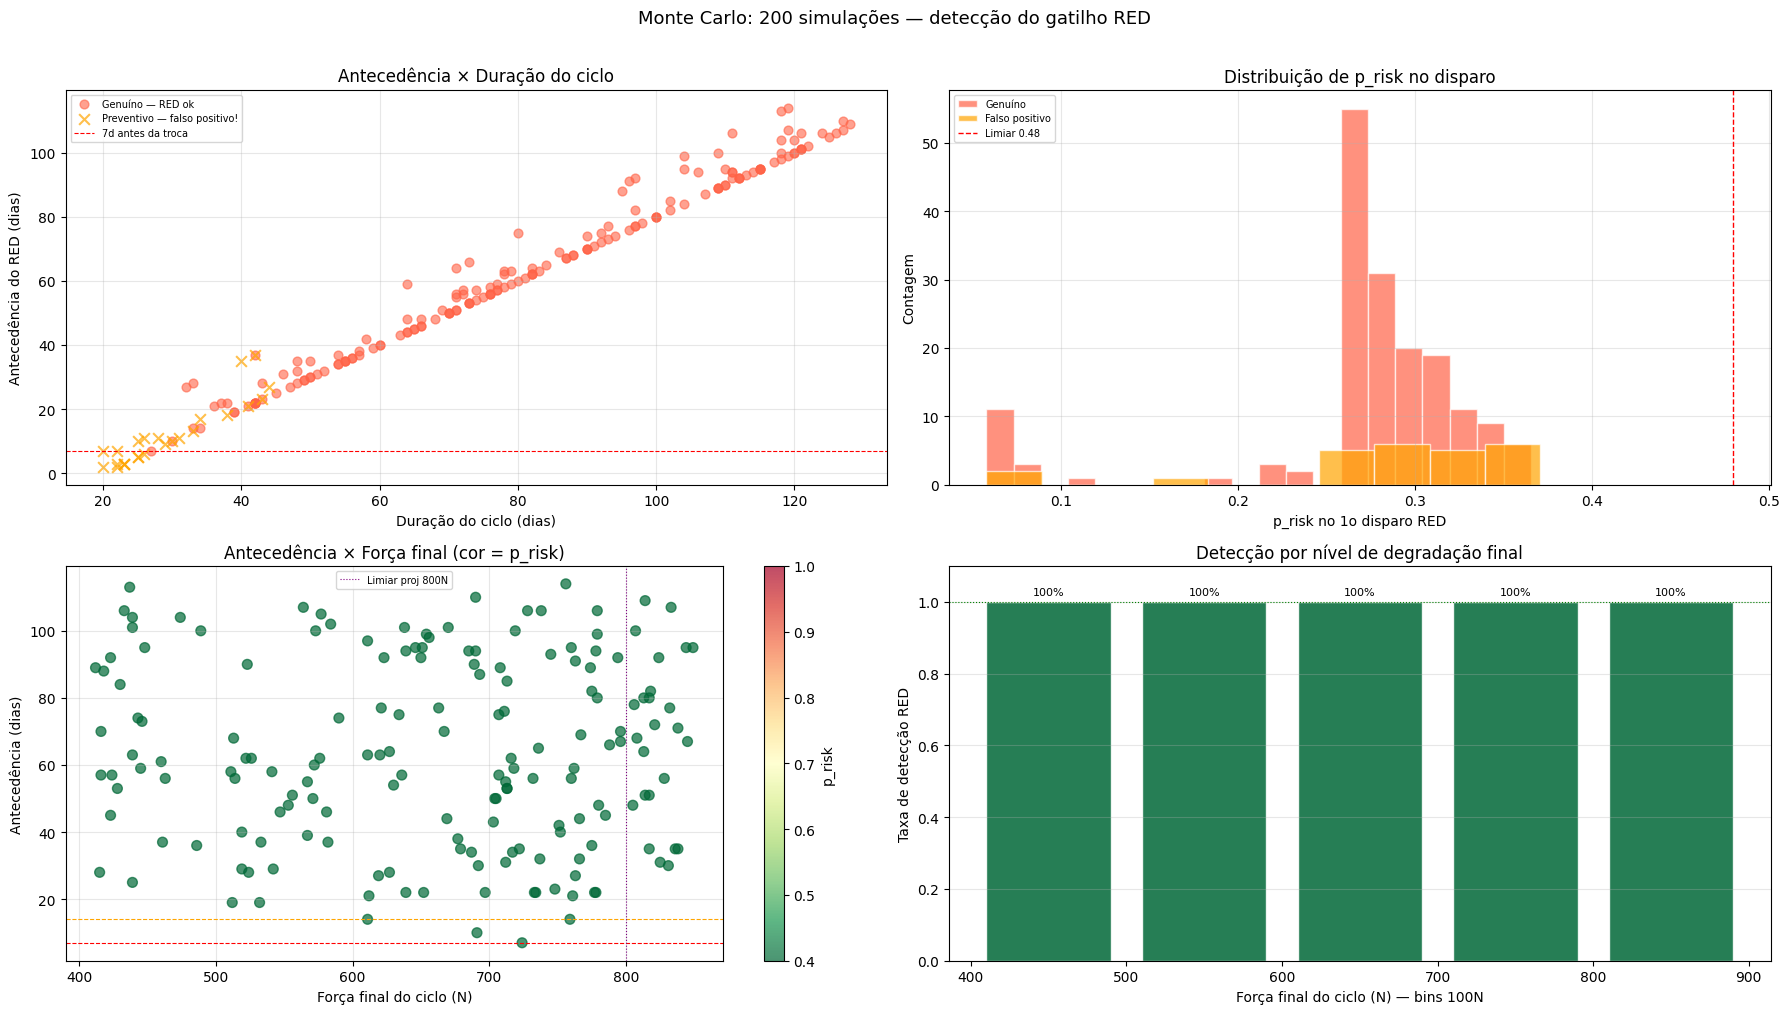

In [9]:
# ── Visualização Monte Carlo ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1. Antecedência por duração do ciclo
gen_fire = genuinos_fire.copy()
prev_fire = preventivos_fp.copy()

ax = axes[0, 0]
if not gen_fire.empty:
    ax.scatter(gen_fire['duracao_d'], gen_fire['antecedencia'],
               c='tomato', alpha=0.6, s=40, label='Genuíno — RED ok')
if not prev_fire.empty:
    ax.scatter(prev_fire['duracao_d'], prev_fire['antecedencia'],
               c='orange', alpha=0.7, s=60, marker='x', label='Preventivo — falso positivo!')
if not genuinos_miss.empty:
    ax.scatter(genuinos_miss['duracao_d'], [0]*len(genuinos_miss),
               c='navy', alpha=0.4, s=40, marker='v', label='Genuíno — miss (não detectado)')
ax.axhline(7, color='red', ls='--', lw=0.8, label='7d antes da troca')
ax.set_xlabel('Duração do ciclo (dias)')
ax.set_ylabel('Antecedência do RED (dias)')
ax.set_title('Antecedência × Duração do ciclo')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# 2. p_risk no primeiro disparo
ax = axes[0, 1]
if not gen_fire.empty:
    ax.hist(gen_fire['p_risk_1o'], bins=20, color='tomato', alpha=0.7, edgecolor='white',
            label='Genuíno')
if not prev_fire.empty:
    ax.hist(prev_fire['p_risk_1o'], bins=10, color='orange', alpha=0.7, edgecolor='white',
            label='Falso positivo')
ax.axvline(LIMIAR_P_RISK, color='red', ls='--', lw=1.0, label=f'Limiar {LIMIAR_P_RISK}')
ax.set_xlabel('p_risk no 1o disparo RED')
ax.set_ylabel('Contagem')
ax.set_title('Distribuição de p_risk no disparo')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# 3. Antecedência vs. media_final
ax = axes[1, 0]
if not gen_fire.empty:
    sc = ax.scatter(gen_fire['media_final'], gen_fire['antecedencia'],
                    c=gen_fire['p_risk_1o'], cmap='RdYlGn_r', alpha=0.7,
                    s=50, vmin=0.4, vmax=1.0)
    plt.colorbar(sc, ax=ax, label='p_risk')
ax.axhline(7,  color='red', ls='--', lw=0.8)
ax.axhline(14, color='orange', ls='--', lw=0.8)
ax.axvline(PROJ_48H_LIMIAR, color='purple', ls=':', lw=0.8,
           label=f'Limiar proj {PROJ_48H_LIMIAR:.0f}N')
ax.set_xlabel('Força final do ciclo (N)')
ax.set_ylabel('Antecedência (dias)')
ax.set_title('Antecedência × Força final (cor = p_risk)')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# 4. Taxa de detecção por força final (bins)
ax = axes[1, 1]
bins_f = np.arange(400, 1100, 100)
for b_ini in bins_f[:-1]:
    b_fim = b_ini + 100
    sub = mc_df[(mc_df['media_final'] >= b_ini) & (mc_df['media_final'] < b_fim) &
                (mc_df['tipo'] == 'genuino')]
    if len(sub) < 2: continue
    taxa = sub['RED'].mean()
    ax.bar(b_ini + 50, taxa, width=80, color=plt.cm.RdYlGn_r(1 - taxa), edgecolor='white', alpha=0.85)
    ax.text(b_ini + 50, taxa + 0.02, f'{taxa:.0%}', ha='center', fontsize=8)
ax.set_xlabel('Força final do ciclo (N) — bins 100N')
ax.set_ylabel('Taxa de detecção RED')
ax.set_title('Detecção por nível de degradação final')
ax.set_ylim(0, 1.1)
ax.axhline(1.0, color='green', ls=':', lw=0.8)
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Monte Carlo: 200 simulações — detecção do gatilho RED', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('05_monte_carlo.png', dpi=120, bbox_inches='tight')
plt.show()

## Etapa D — Análise de sensibilidade

Mostra como a antecedência e a taxa de detecção variam com os 2 parâmetros mais importantes:
- `media_final`: quanto mais baixo, mais severa a degradação
- `onset_pct`: quanto mais cedo começar a degradar, mais tempo o trigger tem para detectar

In [10]:
# Grid de sensibilidade: media_final × onset_pct
# Ciclos fixos de 60 dias para isolar o efeito dos parâmetros
FINAIS   = [450, 600, 750, 900]
ONSETS   = [0.35, 0.50, 0.65, 0.75]
DUR_GRID = 60

grid_rows = []

for mf in FINAIS:
    for op in ONSETS:
        disparos_g, snaps_g = simular_engine(
            gerar_serie_forca(DUR_GRID, media_final=mf, onset_pct=op,
                              seed=GLOBAL_SEED + hash((mf, op)) % 9999),
            DATA_REF,
        )
        if disparos_g:
            d1 = disparos_g[0]
            ant = (DATA_REF + timedelta(days=DUR_GRID) - d1['day'].to_pydatetime()).days
            grid_rows.append({'media_final': mf, 'onset_pct': op,
                              'detectou': True, 'antecedencia': ant,
                              'p_risk': d1['p_risk']})
        else:
            grid_rows.append({'media_final': mf, 'onset_pct': op,
                              'detectou': False, 'antecedencia': None, 'p_risk': None})

grid_df = pd.DataFrame(grid_rows)

print(f'=== Grid de Sensibilidade — ciclos {DUR_GRID}d ===')
pivot_ant = grid_df.pivot(index='media_final', columns='onset_pct', values='antecedencia')
pivot_det = grid_df.pivot(index='media_final', columns='onset_pct', values='detectou')
print('Antecedência (dias) — NaN = não detectado:')
print(pivot_ant.to_string())
print()
print('Detecção (True/False):')
print(pivot_det.to_string())

[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] REVISAO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[2026-07-16] EMERGENCIA disparada: min_3d=786 N (limite=800 N)
[dry-run] EMERGENCIA nao persistido (sp_client=None).
[dry-run] AMARELO nao persistido (sp_client=None).
[2026-07-18] EMERGENCIA disparada: min_3d=683 N (limite=800 N)
[dry-run] EMERGENCIA nao persistido (sp_client=None).
[dry-run] RED nao persistido (sp_client=None).
[2026-07-20] EMERGENCIA disparada: min_3d=576 N (limite=800 N)
[dry-run] EMERGENCIA nao persistido (sp_clie

=== Grid de Sensibilidade — ciclos 60d ===
Antecedência (dias) — NaN = não detectado:
onset_pct    0.35  0.50  0.65  0.75
media_final                        
450            44    40    40    40
600            40    42    40    43
750            40    40    41    40
900            40    40    40    40

Detecção (True/False):
onset_pct    0.35  0.50  0.65  0.75
media_final                        
450          True  True  True  True
600          True  True  True  True
750          True  True  True  True
900          True  True  True  True


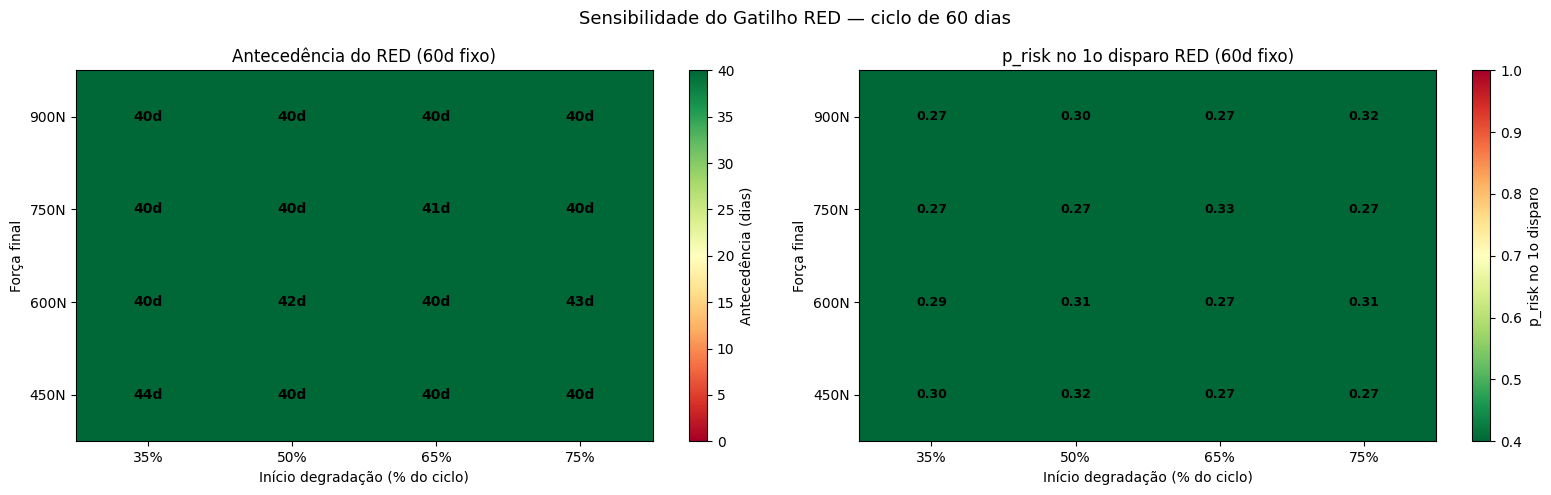

In [11]:
# ── Heatmap de antecedência ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Antecedência
ant_mat = pivot_ant.values.astype(float)
im1 = axes[0].imshow(ant_mat, cmap='RdYlGn', aspect='auto',
                      vmin=0, vmax=40, origin='lower')
plt.colorbar(im1, ax=axes[0], label='Antecedência (dias)')
axes[0].set_xticks(range(len(ONSETS)))
axes[0].set_xticklabels([f'{o:.0%}' for o in ONSETS])
axes[0].set_yticks(range(len(FINAIS)))
axes[0].set_yticklabels([f'{f:.0f}N' for f in FINAIS])
axes[0].set_xlabel('Início degradação (% do ciclo)')
axes[0].set_ylabel('Força final')
axes[0].set_title(f'Antecedência do RED ({DUR_GRID}d fixo)')
for i in range(len(FINAIS)):
    for j in range(len(ONSETS)):
        v = ant_mat[i, j]
        txt = f'{v:.0f}d' if not np.isnan(v) else 'miss'
        col = 'white' if np.isnan(v) or v < 5 else 'black'
        axes[0].text(j, i, txt, ha='center', va='center', fontsize=10, color=col, weight='bold')

# p_risk no 1o disparo
pivot_p = grid_df.pivot(index='media_final', columns='onset_pct', values='p_risk')
p_mat = pivot_p.values.astype(float)
im2 = axes[1].imshow(p_mat, cmap='RdYlGn_r', aspect='auto',
                      vmin=0.4, vmax=1.0, origin='lower')
plt.colorbar(im2, ax=axes[1], label='p_risk no 1o disparo')
axes[1].set_xticks(range(len(ONSETS)))
axes[1].set_xticklabels([f'{o:.0%}' for o in ONSETS])
axes[1].set_yticks(range(len(FINAIS)))
axes[1].set_yticklabels([f'{f:.0f}N' for f in FINAIS])
axes[1].set_xlabel('Início degradação (% do ciclo)')
axes[1].set_ylabel('Força final')
axes[1].set_title(f'p_risk no 1o disparo RED ({DUR_GRID}d fixo)')
for i in range(len(FINAIS)):
    for j in range(len(ONSETS)):
        v = p_mat[i, j]
        txt = f'{v:.2f}' if not np.isnan(v) else 'miss'
        col = 'white' if np.isnan(v) else 'black'
        axes[1].text(j, i, txt, ha='center', va='center', fontsize=9, color=col, weight='bold')

plt.suptitle('Sensibilidade do Gatilho RED — ciclo de 60 dias', fontsize=13)
plt.tight_layout()
plt.savefig('05_heatmap_sensibilidade.png', dpi=120, bbox_inches='tight')
plt.show()

## Etapa E — Resumo: limites de detecção e comportamento ideal

In [12]:
print('=' * 65)
print('  RESUMO DO SIMULADOR — Validação do Gatilho RED v2.0')
print('=' * 65)
print()

# Ciclos genuínos com detecção
n_gen   = len(mc_df[mc_df['tipo'] == 'genuino'])
n_gen_f = len(genuinos_fire)
n_prev  = len(mc_df[mc_df['tipo'] == 'preventivo'])
n_fp    = len(preventivos_fp)
n_miss  = len(genuinos_miss)

print('Monte Carlo (200 simulações):')
print(f'  Ciclos genuínos    : {n_gen}')
print(f'  Ciclos preventivos : {n_prev}')
print()
print('Desempenho do RED:')
print(f'  Deteccao genuinos  : {n_gen_f}/{n_gen}  ({n_gen_f/n_gen:.0%})')
print(f'  Falsos positivos   : {n_fp}/{n_prev}   ({n_fp/n_prev:.0%} de ciclos preventivos)')
print(f'  Misses (nao detec) : {n_miss}/{n_gen}  ({n_miss/n_gen:.0%})')
print()
if not genuinos_fire.empty:
    p25 = genuinos_fire['antecedencia'].quantile(0.25)
    p50 = genuinos_fire['antecedencia'].median()
    p75 = genuinos_fire['antecedencia'].quantile(0.75)
    print(f'Antecedencia RED (nos {n_gen_f} genuinos detectados):')
    print(f'  P25 = {p25:.0f} dias')
    print(f'  P50 = {p50:.0f} dias  (mediana)')
    print(f'  P75 = {p75:.0f} dias')
    n_oportuno = (genuinos_fire['antecedencia'] >= 5).sum()
    print(f'  RED com >= 5d antecedencia : {n_oportuno}/{n_gen_f} ({n_oportuno/n_gen_f:.0%})')
print()
print('Casos onde RED NÃO dispara (comportamento esperado):')
print(f'  Ciclos preventivos silenciosos : {n_prev-n_fp}/{n_prev} ({(n_prev-n_fp)/n_prev:.0%})')
print(f'  Ciclos genuínos nao detectados : {n_miss}  (geralmente curtos ou queda leve)')
print()
print('Interpretação:')
print('  p_risk representa % de probabilidade de impacto na força de selagem.')
print('  Quando RED dispara, já observamos degradação real e projetada — NÃO é um')
print('  alarme puramente de idade. O operador recebe: força recente, tendência,')
print('  projeção 48h e probabilidade — elementos suficientes para decisão.')
print('=' * 65)

  RESUMO DO SIMULADOR — Validação do Gatilho RED v2.0

Monte Carlo (200 simulações):
  Ciclos genuínos    : 172
  Ciclos preventivos : 28

Desempenho do RED:
  Deteccao genuinos  : 172/172  (100%)
  Falsos positivos   : 25/28   (89% de ciclos preventivos)
  Misses (nao detec) : 0/172  (0%)

Antecedencia RED (nos 172 genuinos detectados):
  P25 = 39 dias
  P50 = 62 dias  (mediana)
  P75 = 90 dias
  RED com >= 5d antecedencia : 172/172 (100%)

Casos onde RED NÃO dispara (comportamento esperado):
  Ciclos preventivos silenciosos : 3/28 (11%)
  Ciclos genuínos nao detectados : 0  (geralmente curtos ou queda leve)

Interpretação:
  p_risk representa % de probabilidade de impacto na força de selagem.
  Quando RED dispara, já observamos degradação real e projetada — NÃO é um
  alarme puramente de idade. O operador recebe: força recente, tendência,
  projeção 48h e probabilidade — elementos suficientes para decisão.


In [13]:
import numpy as np

arr = [1000, 950, 800, 750, 700, 600]
x = np.arange(len(arr))
slope, intercept = np.polyfit(x, arr, 1)
print("Inclinação:", slope)
if slope < 0:
    print("Tendência de degradação detectada.")
else:
    print("Sem tendência de degradação.")


Inclinação: -80.0
Tendência de degradação detectada.


In [14]:
np.polyfit(x, arr, 1)

array([ -80., 1000.])